In [1]:
!pip install qiskit qiskit-optimization qiskit-aer -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.0/664.0 kB 9.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.1/237.1 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.9 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

from qiskit_optimization import QuadraticProgram

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

from qiskit_optimization import QuadraticProgram


In [4]:
warehouse_names = ["A", "B", "C"]

opening_cost = np.array([8,6,5])

transport_cost = np.array([
    [2,5,3],
    [4,2,1],
    [3,4,2]
])

customer_demand = np.array([20,15,10])

print(opening_cost)

[8 6 5]


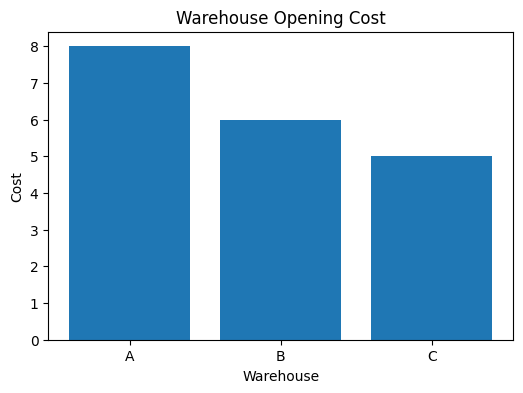

In [5]:
plt.figure(figsize=(6,4))

plt.bar(warehouse_names, opening_cost)

plt.title("Warehouse Opening Cost")

plt.xlabel("Warehouse")

plt.ylabel("Cost")

plt.show()

In [6]:
from qiskit_optimization import QuadraticProgram

qp = QuadraticProgram()

qp.binary_var("A")
qp.binary_var("B")
qp.binary_var("C")

print(qp)

minimize 0 (3 variables, 0 constraints, '')


In [7]:
qp.minimize(
    linear={
        "A":8,
        "B":6,
        "C":5
    }
)

In [8]:
qp.linear_constraint(
    linear={
        "A":1,
        "B":1,
        "C":1
    },
    sense=">=",
    rhs=1,
    name="open_one"
)

<LinearConstraint: A + B + C >= 1 'open_one'>

In [9]:
print(qp.prettyprint())

Problem name: 

Minimize
  8*A + 6*B + 5*C

Subject to
  Linear constraints (1)
    A + B + C >= 1  'open_one'

  Binary variables (3)
    A B C



In [10]:
!pip install qiskit-algorithms -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 7.5 MB/s eta 0:00:00


In [11]:
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_algorithms import NumPyMinimumEigensolver

exact_solver = MinimumEigenOptimizer(NumPyMinimumEigensolver())

result = exact_solver.solve(qp)

print(result)

fval=5.0, A=0.0, B=0.0, C=1.0, status=SUCCESS


In [12]:
print("Optimal Cost:", result.fval)

print("\nSelected Warehouses:")

for variable, value in result.variables_dict.items():
    print(f"{variable} = {value}")

Optimal Cost: 5.0

Selected Warehouses:
A = 0.0
B = 0.0
C = 1.0


In [13]:
import pandas as pd
import numpy as np

# -------------------------
# Warehouse Data
# -------------------------

warehouse_df = pd.DataFrame({
    "Warehouse": ["A", "B", "C"],
    "Opening Cost": [8, 6, 5],
    "Capacity": [40, 30, 20]
})

# -------------------------
# Customer Data
# -------------------------

customer_df = pd.DataFrame({
    "Customer": ["C1", "C2", "C3"],
    "Demand": [20, 15, 10]
})

# -------------------------
# Transportation Cost
# -------------------------

transport_cost = pd.DataFrame(
    [[2,5,3],
     [4,2,1],
     [3,4,2]],
    index=["A","B","C"],
    columns=["C1","C2","C3"]
)

print("Warehouse Data")
display(warehouse_df)

print("\nCustomer Data")
display(customer_df)

print("\nTransportation Cost")
display(transport_cost)

Warehouse Data


,Warehouse,Opening Cost,Capacity
0,A,8,40
1,B,6,30
2,C,5,20



Customer Data


,Customer,Demand
0,C1,20
1,C2,15
2,C3,10



Transportation Cost


,C1,C2,C3
A,2,5,3
B,4,2,1
C,3,4,2


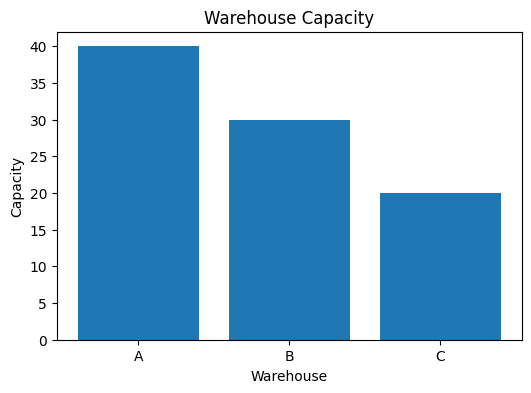

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    warehouse_df["Warehouse"],
    warehouse_df["Capacity"]
)

plt.title("Warehouse Capacity")

plt.xlabel("Warehouse")

plt.ylabel("Capacity")

plt.show()

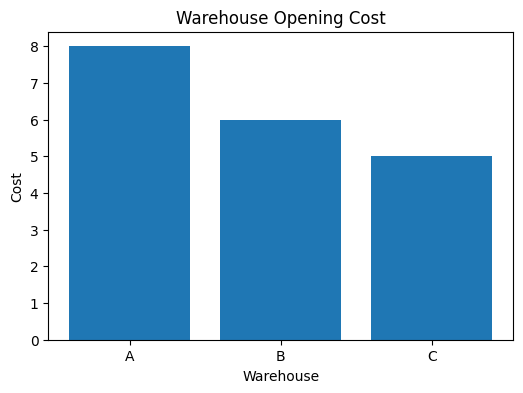

In [15]:
plt.figure(figsize=(6,4))

plt.bar(
    warehouse_df["Warehouse"],
    warehouse_df["Opening Cost"]
)

plt.title("Warehouse Opening Cost")

plt.xlabel("Warehouse")

plt.ylabel("Cost")

plt.show()

# Quantum Supply Chain Optimization using QAOA

## Overview

This project explores how the Quantum Approximate Optimization Algorithm (QAOA) can be applied to a simplified supply chain network optimization problem.

The objective is to minimize warehouse opening and transportation costs while satisfying customer demand and warehouse capacity constraints.

Technologies:
- Python
- Qiskit
- Qiskit Optimization
- IBM Quantum
- Google Colab

Status:
🚧 Work in Progress

In [16]:
!pip show qiskit
!pip show qiskit-optimization

Name: qiskit
Version: 2.5.2
Summary: An open-source SDK for working with quantum computers at the level of extended quantum circuits, operators, and primitives.
Home-page: https://www.ibm.com/quantum/qiskit
Author: 
Author-email: Qiskit Development Team <qiskit@us.ibm.com>
License: 
Location: /usr/local/lib/python3.13/dist-packages
Requires: dill, numpy, rustworkx, scipy, stevedore, typing-extensions
Required-by: qiskit-aer, qiskit-algorithms, qiskit-optimization
Name: qiskit-optimization
Version: 0.7.0
Summary: Qiskit Optimization: A library for optimization applications using quantum computing
Home-page: https://github.com/qiskit-community/qiskit-optimization
Author: Qiskit Optimization Development Team
Author-email: qiskit@us.ibm.com
License: Apache-2.0
Location: /usr/local/lib/python3.13/dist-packages
Requires: docplex, networkx, numpy, qiskit, scipy, setuptools
Required-by: 


In [17]:
!pip install -q qiskit qiskit-optimization qiskit-aer qiskit-algorithms

In [18]:
import qiskit
import qiskit_optimization
import qiskit_algorithms

print("Qiskit Version:", qiskit.__version__)
print("Everything imported successfully!")

Qiskit Version: 2.5.2
Everything imported successfully!


In [19]:
!pip list | grep qiskit
!pip list | findstr qiskit

qiskit                                2.5.2
qiskit-aer                            0.17.2
qiskit-algorithms                     0.4.0
qiskit-optimization                   0.7.0
/bin/bash: line 1: findstr: command not found
ERROR: Pipe to stdout was broken
Exception ignored on flushing sys.stdout:
BrokenPipeError: [Errno 32] Broken pipe


In [20]:
from qiskit_optimization import QuadraticProgram

qp = QuadraticProgram("SupplyChainOptimization")
warehouses = ["A", "B", "C"]

for warehouse in warehouses:
    qp.binary_var(name=f"x_{warehouse}")



In [21]:
print(qp.variables)

[<Variable: x_A (binary)>, <Variable: x_B (binary)>, <Variable: x_C (binary)>]


In [22]:
customers = ["C1", "C2", "C3"]

for warehouse in warehouses:
    for customer in customers:
        qp.binary_var(name=f"y_{warehouse}_{customer}")

In [23]:
print(qp.variables)

[<Variable: x_A (binary)>, <Variable: x_B (binary)>, <Variable: x_C (binary)>, <Variable: y_A_C1 (binary)>, <Variable: y_A_C2 (binary)>, <Variable: y_A_C3 (binary)>, <Variable: y_B_C1 (binary)>, <Variable: y_B_C2 (binary)>, <Variable: y_B_C3 (binary)>, <Variable: y_C_C1 (binary)>, <Variable: y_C_C2 (binary)>, <Variable: y_C_C3 (binary)>]


In [24]:
print("Total Variables =", qp.get_num_vars())

Total Variables = 12


In [25]:
print("Total Variables =", qp.get_num_vars())

print(qp.prettyprint())

Total Variables = 12
Problem name: SupplyChainOptimization

Minimize
  0

Subject to
  No constraints

  Binary variables (12)
    x_A x_B x_C y_A_C1 y_A_C2 y_A_C3 y_B_C1 y_B_C2 y_B_C3 y_C_C1 y_C_C2 y_C_C3



In [26]:
# Opening costs
opening_cost = {
    "A": 8,
    "B": 6,
    "C": 5
}

# Transportation costs
transport_cost = {
    ("A","C1"):2,
    ("A","C2"):5,
    ("A","C3"):3,

    ("B","C1"):4,
    ("B","C2"):2,
    ("B","C3"):1,

    ("C","C1"):3,
    ("C","C2"):4,
    ("C","C3"):2
}

In [27]:
objective = {}

# Warehouse opening cost
for warehouse in warehouses:
    objective[f"x_{warehouse}"] = opening_cost[warehouse]

# Transportation cost
for warehouse in warehouses:
    for customer in customers:
        objective[f"y_{warehouse}_{customer}"] = transport_cost[(warehouse, customer)]

In [28]:
qp.minimize(linear=objective)

In [29]:
print(qp.prettyprint())

Problem name: SupplyChainOptimization

Minimize
  8*x_A + 6*x_B + 5*x_C + 2*y_A_C1 + 5*y_A_C2 + 3*y_A_C3 + 4*y_B_C1 + 2*y_B_C2
  + y_B_C3 + 3*y_C_C1 + 4*y_C_C2 + 2*y_C_C3

Subject to
  No constraints

  Binary variables (12)
    x_A x_B x_C y_A_C1 y_A_C2 y_A_C3 y_B_C1 y_B_C2 y_B_C3 y_C_C1 y_C_C2 y_C_C3



In [30]:
# Every customer must be assigned to exactly one warehouse

for customer in customers:

    linear = {}

    for warehouse in warehouses:
        linear[f"y_{warehouse}_{customer}"] = 1

    qp.linear_constraint(
        linear=linear,
        sense="==",
        rhs=1,
        name=f"assign_{customer}"
    )

In [31]:
print(qp.prettyprint())

Problem name: SupplyChainOptimization

Minimize
  8*x_A + 6*x_B + 5*x_C + 2*y_A_C1 + 5*y_A_C2 + 3*y_A_C3 + 4*y_B_C1 + 2*y_B_C2
  + y_B_C3 + 3*y_C_C1 + 4*y_C_C2 + 2*y_C_C3

Subject to
  Linear constraints (3)
    y_A_C1 + y_B_C1 + y_C_C1 == 1  'assign_C1'
    y_A_C2 + y_B_C2 + y_C_C2 == 1  'assign_C2'
    y_A_C3 + y_B_C3 + y_C_C3 == 1  'assign_C3'

  Binary variables (12)
    x_A x_B x_C y_A_C1 y_A_C2 y_A_C3 y_B_C1 y_B_C2 y_B_C3 y_C_C1 y_C_C2 y_C_C3



In [32]:
# Link assignment variables to warehouse opening

for warehouse in warehouses:
    for customer in customers:

        qp.linear_constraint(
            linear={
                f"y_{warehouse}_{customer}": 1,
                f"x_{warehouse}": -1
            },
            sense="<=",
            rhs=0,
            name=f"link_{warehouse}_{customer}"
        )

In [33]:
print(qp.prettyprint())

Problem name: SupplyChainOptimization

Minimize
  8*x_A + 6*x_B + 5*x_C + 2*y_A_C1 + 5*y_A_C2 + 3*y_A_C3 + 4*y_B_C1 + 2*y_B_C2
  + y_B_C3 + 3*y_C_C1 + 4*y_C_C2 + 2*y_C_C3

Subject to
  Linear constraints (12)
    y_A_C1 + y_B_C1 + y_C_C1 == 1  'assign_C1'
    y_A_C2 + y_B_C2 + y_C_C2 == 1  'assign_C2'
    y_A_C3 + y_B_C3 + y_C_C3 == 1  'assign_C3'
    -x_A + y_A_C1 <= 0  'link_A_C1'
    -x_A + y_A_C2 <= 0  'link_A_C2'
    -x_A + y_A_C3 <= 0  'link_A_C3'
    -x_B + y_B_C1 <= 0  'link_B_C1'
    -x_B + y_B_C2 <= 0  'link_B_C2'
    -x_B + y_B_C3 <= 0  'link_B_C3'
    -x_C + y_C_C1 <= 0  'link_C_C1'
    -x_C + y_C_C2 <= 0  'link_C_C2'
    -x_C + y_C_C3 <= 0  'link_C_C3'

  Binary variables (12)
    x_A x_B x_C y_A_C1 y_A_C2 y_A_C3 y_B_C1 y_B_C2 y_B_C3 y_C_C1 y_C_C2 y_C_C3



In [34]:
capacity = {
    "A": 40,
    "B": 30,
    "C": 20
}

demand = {
    "C1": 20,
    "C2": 15,
    "C3": 10
}

In [35]:
for warehouse in warehouses:

    linear = {}

    # Add customer demand terms
    for customer in customers:
        linear[f"y_{warehouse}_{customer}"] = demand[customer]

    # Subtract warehouse capacity
    linear[f"x_{warehouse}"] = -capacity[warehouse]

    qp.linear_constraint(
        linear=linear,
        sense="<=",
        rhs=0,
        name=f"capacity_{warehouse}"
    )

In [36]:
print(qp.prettyprint())

Problem name: SupplyChainOptimization

Minimize
  8*x_A + 6*x_B + 5*x_C + 2*y_A_C1 + 5*y_A_C2 + 3*y_A_C3 + 4*y_B_C1 + 2*y_B_C2
  + y_B_C3 + 3*y_C_C1 + 4*y_C_C2 + 2*y_C_C3

Subject to
  Linear constraints (15)
    y_A_C1 + y_B_C1 + y_C_C1 == 1  'assign_C1'
    y_A_C2 + y_B_C2 + y_C_C2 == 1  'assign_C2'
    y_A_C3 + y_B_C3 + y_C_C3 == 1  'assign_C3'
    -x_A + y_A_C1 <= 0  'link_A_C1'
    -x_A + y_A_C2 <= 0  'link_A_C2'
    -x_A + y_A_C3 <= 0  'link_A_C3'
    -x_B + y_B_C1 <= 0  'link_B_C1'
    -x_B + y_B_C2 <= 0  'link_B_C2'
    -x_B + y_B_C3 <= 0  'link_B_C3'
    -x_C + y_C_C1 <= 0  'link_C_C1'
    -x_C + y_C_C2 <= 0  'link_C_C2'
    -x_C + y_C_C3 <= 0  'link_C_C3'
    -40*x_A + 20*y_A_C1 + 15*y_A_C2 + 10*y_A_C3 <= 0  'capacity_A'
    -30*x_B + 20*y_B_C1 + 15*y_B_C2 + 10*y_B_C3 <= 0  'capacity_B'
    -20*x_C + 20*y_C_C1 + 15*y_C_C2 + 10*y_C_C3 <= 0  'capacity_C'

  Binary variables (12)
    x_A x_B x_C y_A_C1 y_A_C2 y_A_C3 y_B_C1 y_B_C2 y_B_C3 y_C_C1 y_C_C2 y_C_C3



In [37]:
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_algorithms import NumPyMinimumEigensolver

In [38]:
exact_solver = MinimumEigenOptimizer(
    NumPyMinimumEigensolver()
)

In [ ]:
result = exact_solver.solve(qp)

In [ ]:
print(result)

In [ ]:
print("=" * 50)
print("OPTIMAL SOLUTION")
print("=" * 50)

print(f"\nMinimum Cost = {result.fval}")

print("\nWarehouse Decisions")

for w in warehouses:
    print(f"{w}: {'OPEN' if result.variables_dict[f'x_{w}'] == 1 else 'CLOSED'}")

print("\nCustomer Assignments")

for w in warehouses:
    for c in customers:
        if result.variables_dict[f"y_{w}_{c}"] == 1:
            print(f"{c} is served by Warehouse {w}")

In [ ]:
from qiskit_optimization.converters import QuadraticProgramToQubo

In [ ]:
qubo_converter = QuadraticProgramToQubo()

In [ ]:
qubo = qubo_converter.convert(qp)

In [ ]:
print(qubo.prettyprint())

In [ ]:
from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit_optimization.algorithms import MinimumEigenOptimizer

In [ ]:
exact = MinimumEigenOptimizer(
    NumPyMinimumEigensolver()
)
qubo_result = exact.solve(qubo)
print(qubo_result)

In [ ]:
print("="*60)
print("QUBO SOLUTION")
print("="*60)

print(f"Objective Value: {qubo_result.fval}")

for variable, value in qubo_result.variables_dict.items():
    print(f"{variable}: {value}")

In [ ]:
print(qubo.prettyprint())
print("Original variables:", qp.get_num_vars())
print("QUBO variables:", qubo.get_num_vars())
print("Original constraints:", qp.get_num_linear_constraints())
print("QUBO constraints:", qubo.get_num_linear_constraints())

In [ ]:
print(qp.prettyprint())